In [16]:
# Install libraries
!pip install pandas numpy scikit-learn matplotlib seaborn imbalanced-learn -q

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score,
                             precision_score, recall_score)
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully ✅")

All libraries imported successfully ✅


In [17]:

from sklearn.datasets import make_classification
import pandas as pd
import numpy as np

np.random.seed(42)
n = 10000

df = pd.DataFrame({
    'age':                    np.random.randint(18, 75, n),
    'income':                 np.random.randint(20000, 200000, n),
    'loan_amount':            np.random.randint(1000, 50000, n),
    'loan_tenure_months':     np.random.randint(6, 60, n),
    'avg_dpd_per_delinquency':np.random.randint(0, 90, n),
    'delinquency_ratio':      np.round(np.random.uniform(0, 1, n), 2),
    'credit_utilization_ratio':np.round(np.random.uniform(0, 1, n), 2),
    'num_open_accounts':      np.random.randint(1, 15, n),
    'residence_type':         np.random.choice(['Owned', 'Rented', 'Mortgage'], n),
    'loan_purpose':           np.random.choice(['Education', 'Home', 'Auto', 'Personal'], n),
    'loan_type':              np.random.choice(['Secured', 'Unsecured'], n),
})


default_prob = (
    0.3 * (df['delinquency_ratio'] > 0.5).astype(int) +
    0.3 * (df['avg_dpd_per_delinquency'] > 45).astype(int) +
    0.2 * (df['credit_utilization_ratio'] > 0.7).astype(int) +
    0.2 * (df['income'] < 50000).astype(int)
)
df['default'] = (default_prob + np.random.uniform(0, 0.3, n) > 0.5).astype(int)

print("Shape:", df.shape)
print("\nDefault distribution:")
print(df['default'].value_counts())
print("\nFirst 5 rows:")
df.head()

Shape: (10000, 12)

Default distribution:
default
1    5603
0    4397
Name: count, dtype: int64

First 5 rows:


,age,income,loan_amount,loan_tenure_months,avg_dpd_per_delinquency,delinquency_ratio,credit_utilization_ratio,num_open_accounts,residence_type,loan_purpose,loan_type,default
0,56,90309,5081,15,83,0.89,0.66,11,Owned,Auto,Secured,1
1,69,163518,40222,23,64,0.97,0.98,9,Rented,Personal,Unsecured,1
2,46,181805,9933,17,54,0.70,0.40,2,Rented,Education,Secured,1
3,32,139156,3671,44,23,0.12,0.55,13,Rented,Home,Unsecured,0
4,60,96000,44739,31,24,0.49,0.53,7,Rented,Home,Unsecured,0


In [18]:
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total Records : {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")

print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Basic Statistics ---")
df.describe()

DATASET OVERVIEW
Total Records : 10000
Total Features: 12

--- Data Types ---
age                           int64
income                        int64
loan_amount                   int64
loan_tenure_months            int64
avg_dpd_per_delinquency       int64
delinquency_ratio           float64
credit_utilization_ratio    float64
num_open_accounts             int64
residence_type               object
loan_purpose                 object
loan_type                    object
default                       int64
dtype: object

--- Missing Values ---
age                         0
income                      0
loan_amount                 0
loan_tenure_months          0
avg_dpd_per_delinquency     0
delinquency_ratio           0
credit_utilization_ratio    0
num_open_accounts           0
residence_type              0
loan_purpose                0
loan_type                   0
default                     0
dtype: int64

--- Basic Statistics ---


,age,income,loan_amount,loan_tenure_months,avg_dpd_per_delinquency,delinquency_ratio,credit_utilization_ratio,num_open_accounts,default
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,46.166100,109178.407500,25397.201800,32.527300,44.611600,0.499447,0.498246,7.547700,0.560300
std,16.421738,51965.802834,14102.421489,15.505376,25.855436,0.288753,0.288811,4.016832,0.496375
min,18.000000,20005.000000,1008.000000,6.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,32.000000,64085.000000,13365.250000,19.000000,22.000000,0.250000,0.250000,4.000000,0.000000
50%,46.000000,109046.000000,25094.500000,32.000000,45.000000,0.500000,0.500000,8.000000,1.000000
75%,61.000000,154185.000000,37433.250000,46.000000,67.000000,0.750000,0.750000,11.000000,1.000000
max,74.000000,199992.000000,49991.000000,59.000000,89.000000,1.000000,1.000000,14.000000,1.000000


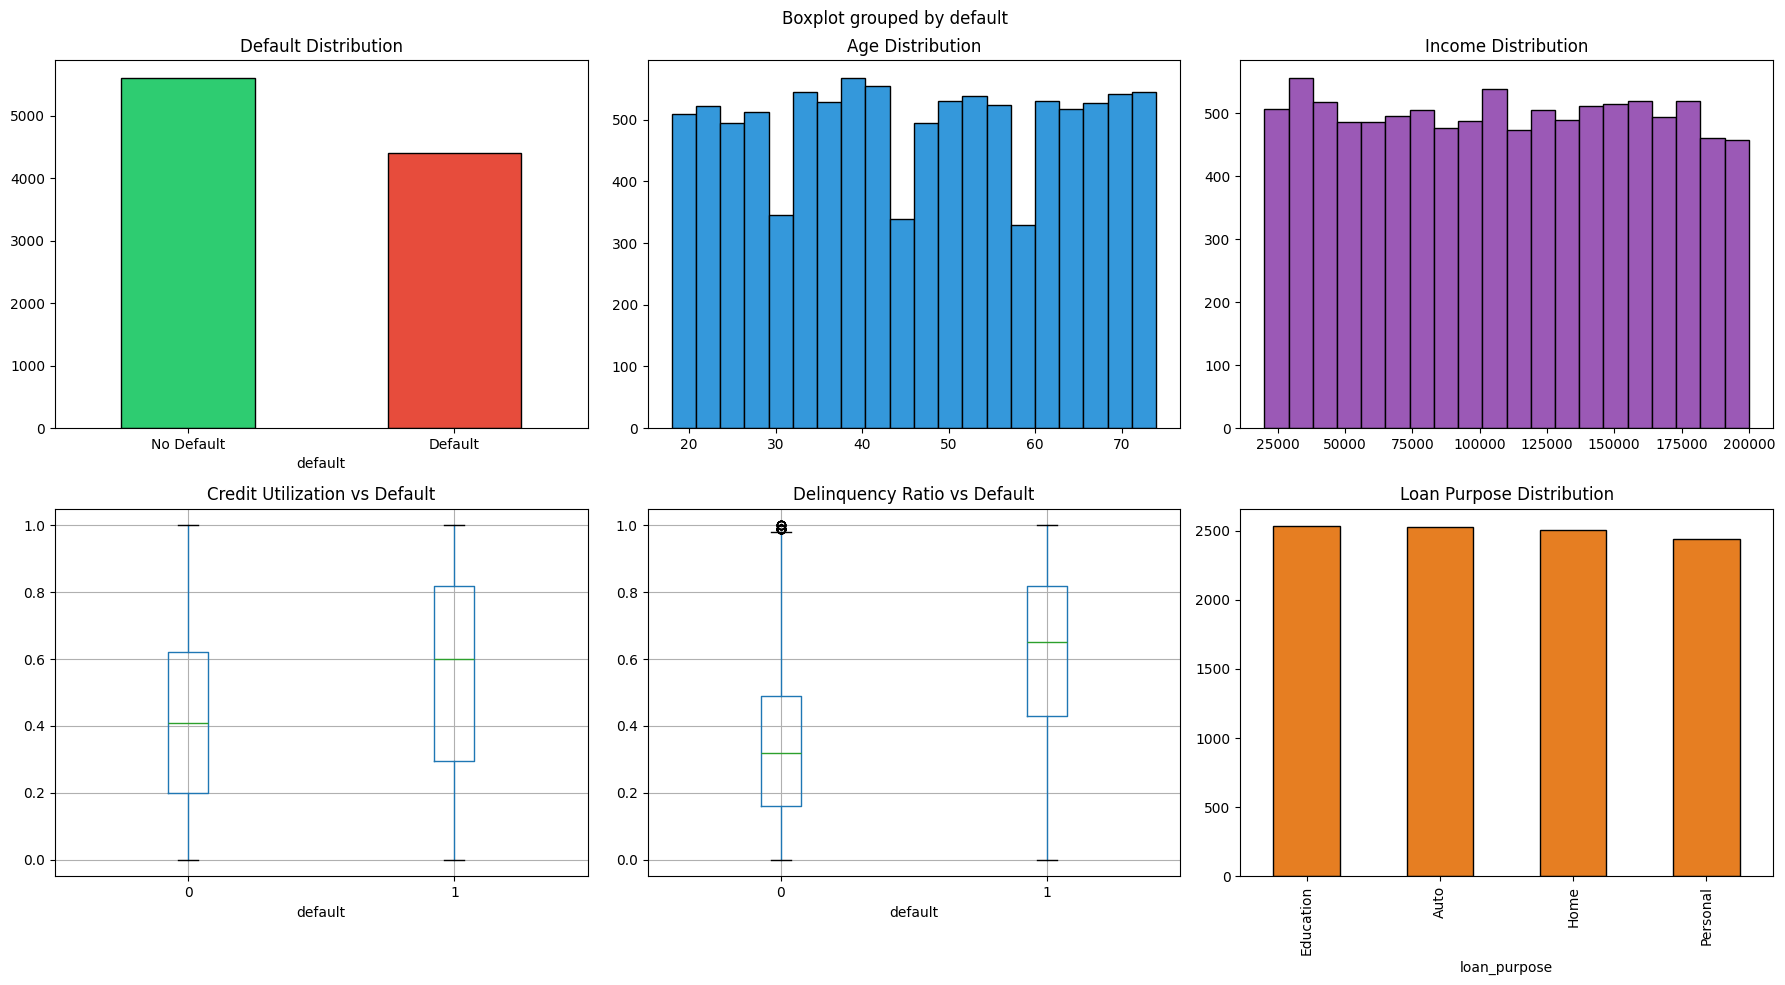

EDA Complete ✅


In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))


df['default'].value_counts().plot(kind='bar', ax=axes[0,0],
    color=['#2ecc71','#e74c3c'], edgecolor='black')
axes[0,0].set_title('Default Distribution')
axes[0,0].set_xticklabels(['No Default','Default'], rotation=0)


axes[0,1].hist(df['age'], bins=20, color='#3498db', edgecolor='black')
axes[0,1].set_title('Age Distribution')


axes[0,2].hist(df['income'], bins=20, color='#9b59b6', edgecolor='black')
axes[0,2].set_title('Income Distribution')


df.boxplot(column='credit_utilization_ratio', by='default', ax=axes[1,0])
axes[1,0].set_title('Credit Utilization vs Default')


df.boxplot(column='delinquency_ratio', by='default', ax=axes[1,1])
axes[1,1].set_title('Delinquency Ratio vs Default')


df['loan_purpose'].value_counts().plot(kind='bar', ax=axes[1,2],
    color='#e67e22', edgecolor='black')
axes[1,2].set_title('Loan Purpose Distribution')

plt.tight_layout()
plt.show()
print("EDA Complete ✅")

In [20]:
print("Starting Data Preprocessing... ⏳")


df_model = df.copy()

df_model['residence_type'] = df_model['residence_type'].map({
    'Owned': 2, 'Mortgage': 1, 'Rented': 0
})

df_model['loan_purpose'] = df_model['loan_purpose'].map({
    'Home': 3, 'Auto': 2, 'Education': 1, 'Personal': 0
})

df_model['loan_type'] = df_model['loan_type'].map({
    'Secured': 1, 'Unsecured': 0
})

df_model['debt_to_income']     = df_model['loan_amount'] / df_model['income']
df_model['loan_to_tenure']     = df_model['loan_amount'] / df_model['loan_tenure_months']
df_model['risk_score']         = (
    df_model['delinquency_ratio'] * 0.4 +
    df_model['credit_utilization_ratio'] * 0.3 +
    df_model['avg_dpd_per_delinquency'] / 90 * 0.3
)

print("New features created:")
print("  ✅ debt_to_income")
print("  ✅ loan_to_tenure")
print("  ✅ risk_score")


X = df_model.drop('default', axis=1)
y = df_model['default']

print(f"\nFeatures shape : {X.shape}")
print(f"Target shape   : {y.shape}")


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size: {X_train.shape[0]}")
print(f"Test size : {X_test.shape[0]}")

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"  Class 0: {sum(y_train_sm == 0)}")
print(f"  Class 1: {sum(y_train_sm == 1)}")


scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)

print("\nData Preprocessing Complete ✅")

Starting Data Preprocessing... ⏳
New features created:
  ✅ debt_to_income
  ✅ loan_to_tenure
  ✅ risk_score

Features shape : (10000, 14)
Target shape   : (10000,)

Train size: 8000
Test size : 2000

After SMOTE:
  Class 0: 4482
  Class 1: 4482

Data Preprocessing Complete ✅


In [21]:
print("Training Models... ⏳")
print("=" * 50)


print("\n1️⃣ Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_sc, y_train_sm)
lr_pred  = lr_model.predict(X_test_sc)
lr_proba = lr_model.predict_proba(X_test_sc)[:,1]
print("   Done ✅")


print("\n2️⃣ Training Decision Tree...")
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train_sc, y_train_sm)
dt_pred  = dt_model.predict(X_test_sc)
dt_proba = dt_model.predict_proba(X_test_sc)[:,1]
print("   Done ✅")


print("\n3️⃣ Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_sc, y_train_sm)
rf_pred  = rf_model.predict(X_test_sc)
rf_proba = rf_model.predict_proba(X_test_sc)[:,1]
print("   Done ✅")


results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy':  [
        round((lr_pred == y_test).mean() * 100, 2),
        round((dt_pred == y_test).mean() * 100, 2),
        round((rf_pred == y_test).mean() * 100, 2)
    ],
    'ROC-AUC': [
        round(roc_auc_score(y_test, lr_proba) * 100, 2),
        round(roc_auc_score(y_test, dt_proba) * 100, 2),
        round(roc_auc_score(y_test, rf_proba) * 100, 2)
    ],
    'F1-Score': [
        round(f1_score(y_test, lr_pred) * 100, 2),
        round(f1_score(y_test, dt_pred) * 100, 2),
        round(f1_score(y_test, rf_pred) * 100, 2)
    ]
})

print("\n" + "=" * 50)
print("MODEL COMPARISON SUMMARY")
print("=" * 50)
print(results.to_string(index=False))
print("\nAll Models Trained ✅")

Training Models... ⏳

1️⃣ Training Logistic Regression...
   Done ✅

2️⃣ Training Decision Tree...
   Done ✅

3️⃣ Training Random Forest...
   Done ✅

MODEL COMPARISON SUMMARY
              Model  Accuracy  ROC-AUC  F1-Score
Logistic Regression     79.55    88.91     81.30
      Decision Tree     88.85    94.69     89.53
      Random Forest     88.80    96.28     89.34

All Models Trained ✅


FULL EVALUATION REPORT

  Logistic Regression
  Accuracy  : 79.55%
  Precision : 83.4%
  Recall    : 79.3%
  F1-Score  : 81.3%
  ROC-AUC   : 88.91%

  Classification Report:
              precision    recall  f1-score   support

  No Default       0.75      0.80      0.77       879
     Default       0.83      0.79      0.81      1121

    accuracy                           0.80      2000
   macro avg       0.79      0.80      0.79      2000
weighted avg       0.80      0.80      0.80      2000



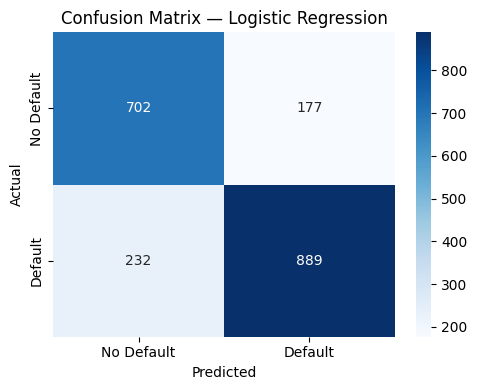


  Decision Tree
  Accuracy  : 88.85%
  Precision : 94.54%
  Recall    : 85.01%
  F1-Score  : 89.53%
  ROC-AUC   : 94.69%

  Classification Report:
              precision    recall  f1-score   support

  No Default       0.83      0.94      0.88       879
     Default       0.95      0.85      0.90      1121

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000



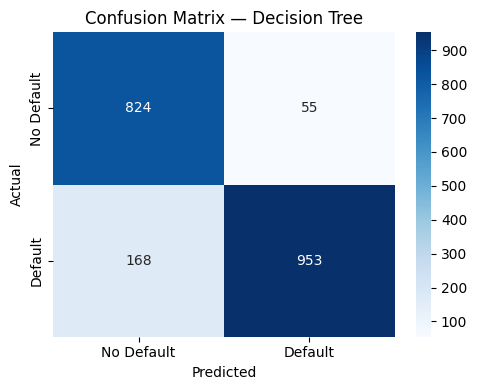


  Random Forest
  Accuracy  : 88.8%
  Precision : 95.72%
  Recall    : 83.76%
  F1-Score  : 89.34%
  ROC-AUC   : 96.28%

  Classification Report:
              precision    recall  f1-score   support

  No Default       0.82      0.95      0.88       879
     Default       0.96      0.84      0.89      1121

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.90      0.89      0.89      2000



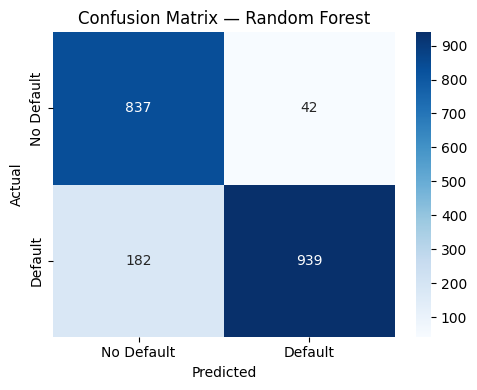


Evaluation Complete ✅


In [22]:
print("=" * 50)
print("FULL EVALUATION REPORT")
print("=" * 50)

models = {
    'Logistic Regression': (lr_pred, lr_proba),
    'Decision Tree':       (dt_pred, dt_proba),
    'Random Forest':       (rf_pred, rf_proba)
}

for name, (pred, proba) in models.items():
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {round((pred == y_test).mean() * 100, 2)}%")
    print(f"  Precision : {round(precision_score(y_test, pred) * 100, 2)}%")
    print(f"  Recall    : {round(recall_score(y_test, pred) * 100, 2)}%")
    print(f"  F1-Score  : {round(f1_score(y_test, pred) * 100, 2)}%")
    print(f"  ROC-AUC   : {round(roc_auc_score(y_test, proba) * 100, 2)}%")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, pred,
          target_names=['No Default', 'Default']))


    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Default','Default'],
                yticklabels=['No Default','Default'])
    plt.title(f'Confusion Matrix — {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

print("\nEvaluation Complete ✅")

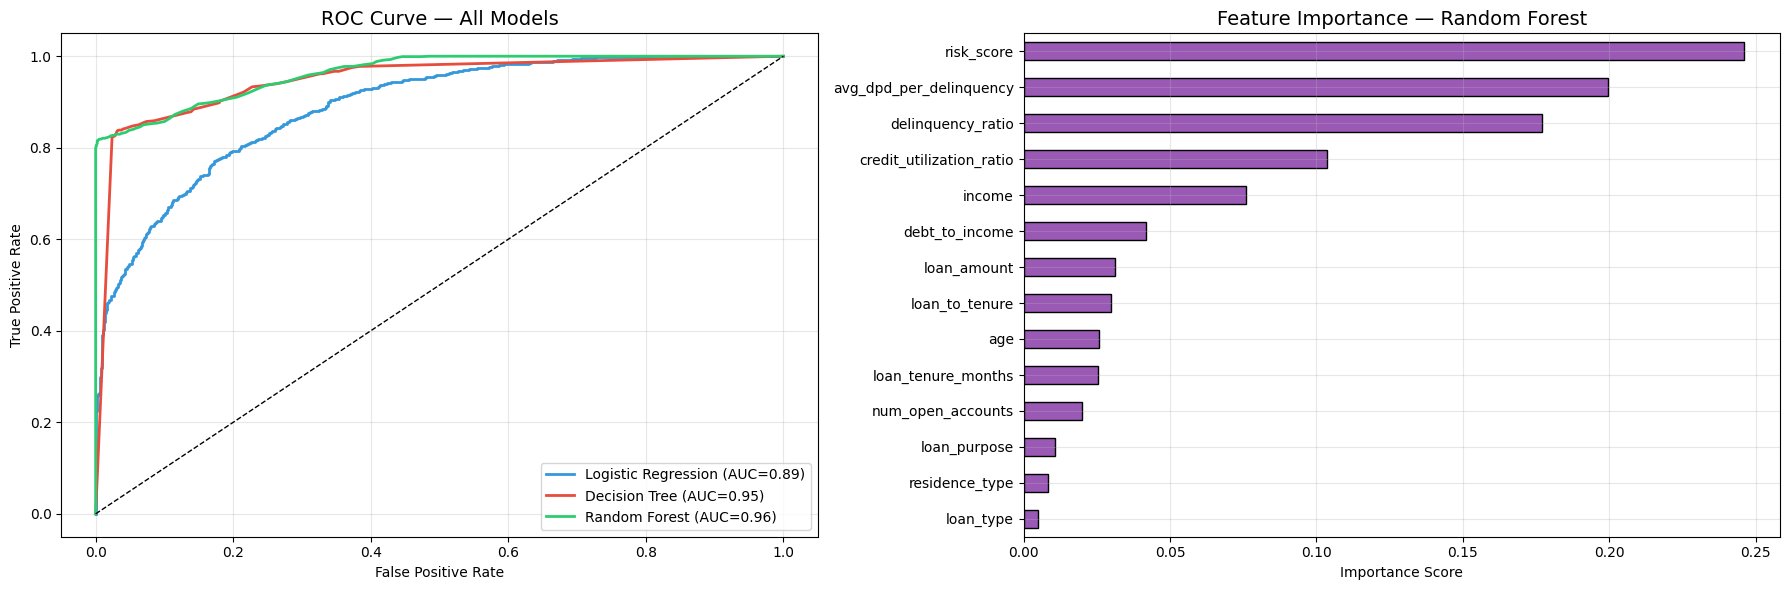

        FINAL MODEL RECOMMENDATION

  🏆 Best Model  : Random Forest
  ✅ Accuracy    : 88.8%
  ✅ ROC-AUC     : 96.28%
  ✅ F1-Score    : 89.34%

  Top 3 Important Features:
  1. risk_score (0.2460)
  2. avg_dpd_per_delinquency (0.1994)
  3. delinquency_ratio (0.1770)

🎉 Credit Scoring Model Complete!


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── 1. ROC Curves ──
models_roc = {
    'Logistic Regression': lr_proba,
    'Decision Tree':       dt_proba,
    'Random Forest':       rf_proba
}
colors = ['#3498db', '#e74c3c', '#2ecc71']

for (name, proba), color in zip(models_roc.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc          = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.2f})', color=color, lw=2)

axes[0].plot([0,1], [0,1], 'k--', lw=1)
axes[0].set_title('ROC Curve — All Models', fontsize=14)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# ── 2. Feature Importance (Random Forest) ──
feat_imp = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

feat_imp.plot(kind='barh', ax=axes[1], color='#9b59b6', edgecolor='black')
axes[1].set_title('Feature Importance — Random Forest', fontsize=14)
axes[1].set_xlabel('Importance Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Final Summary ──
print("=" * 50)
print("        FINAL MODEL RECOMMENDATION")
print("=" * 50)

best_idx = results['ROC-AUC'].idxmax()
best     = results.loc[best_idx]

print(f"\n  🏆 Best Model  : {best['Model']}")
print(f"  ✅ Accuracy    : {best['Accuracy']}%")
print(f"  ✅ ROC-AUC     : {best['ROC-AUC']}%")
print(f"  ✅ F1-Score    : {best['F1-Score']}%")
print(f"\n  Top 3 Important Features:")
top3 = feat_imp.sort_values(ascending=False).head(3)
for i, (feat, score) in enumerate(top3.items(), 1):
    print(f"  {i}. {feat} ({score:.4f})")

print("\n🎉 Credit Scoring Model Complete!")

In [24]:
!pip install gradio -q

import gradio as gr
import numpy as np

# Label mapping
label_map = {0: "✅ No Default", 1: "❌ Default"}

def predict_credit(age, income, loan_amount, loan_tenure_months,
                   avg_dpd, delinquency_ratio, credit_utilization,
                   num_open_accounts, residence_type, loan_purpose, loan_type):

    # Encode categoricals
    residence_map = {'Owned': 2, 'Mortgage': 1, 'Rented': 0}
    purpose_map   = {'Home': 3, 'Auto': 2, 'Education': 1, 'Personal': 0}
    type_map      = {'Secured': 1, 'Unsecured': 0}

    # Feature engineering
    debt_to_income = loan_amount / income
    loan_to_tenure = loan_amount / loan_tenure_months
    risk_score     = (delinquency_ratio * 0.4 +
                      credit_utilization * 0.3 +
                      avg_dpd / 90 * 0.3)

    # Build input array
    features = np.array([[
        age, income, loan_amount, loan_tenure_months,
        avg_dpd, delinquency_ratio, credit_utilization,
        num_open_accounts,
        residence_map[residence_type],
        purpose_map[loan_purpose],
        type_map[loan_type],
        debt_to_income, loan_to_tenure, risk_score
    ]])

    # Scale
    features_scaled = scaler.transform(features)

    # Predict
    prediction = rf_model.predict(features_scaled)[0]
    proba      = rf_model.predict_proba(features_scaled)[0]
    confidence = round(max(proba) * 100, 2)

    result = label_map[prediction]
    detail = (
        f"### {result}\n\n"
        f"**Confidence:** {confidence}%\n\n"
        f"**No Default Probability:** {round(proba[0]*100, 2)}%\n\n"
        f"**Default Probability:** {round(proba[1]*100, 2)}%\n\n"
        f"**Risk Score:** {round(risk_score, 4)}"
    )
    return detail

# Build Gradio UI
with gr.Blocks(title="Credit Scoring Model", theme=gr.themes.Soft()) as demo:

    gr.Markdown("# 💳 Credit Scoring Predictor")
    gr.Markdown("Enter the applicant's financial details to predict creditworthiness.")

    with gr.Row():
        with gr.Column():
            gr.Markdown("### 👤 Personal Info")
            age             = gr.Slider(18, 75, value=35, label="Age")
            income          = gr.Number(value=60000, label="Annual Income ($)")
            residence_type  = gr.Dropdown(['Owned','Rented','Mortgage'],
                                          value='Owned', label="Residence Type")

        with gr.Column():
            gr.Markdown("### 💰 Loan Details")
            loan_amount          = gr.Number(value=15000, label="Loan Amount ($)")
            loan_tenure_months   = gr.Slider(6, 60, value=24, label="Loan Tenure (Months)")
            loan_purpose         = gr.Dropdown(['Home','Auto','Education','Personal'],
                                               value='Personal', label="Loan Purpose")
            loan_type            = gr.Dropdown(['Secured','Unsecured'],
                                               value='Unsecured', label="Loan Type")

        with gr.Column():
            gr.Markdown("### 📊 Credit History")
            avg_dpd              = gr.Slider(0, 90, value=10,
                                             label="Avg Days Past Due (DPD)")
            delinquency_ratio    = gr.Slider(0.0, 1.0, value=0.2, step=0.01,
                                             label="Delinquency Ratio")
            credit_utilization   = gr.Slider(0.0, 1.0, value=0.3, step=0.01,
                                             label="Credit Utilization Ratio")
            num_open_accounts    = gr.Slider(1, 15, value=3,
                                             label="Number of Open Accounts")

    predict_btn = gr.Button("🔍 Predict Creditworthiness", variant="primary")

    output = gr.Markdown(label="Prediction Result")

    predict_btn.click(
        fn=predict_credit,
        inputs=[age, income, loan_amount, loan_tenure_months,
                avg_dpd, delinquency_ratio, credit_utilization,
                num_open_accounts, residence_type, loan_purpose, loan_type],
        outputs=output
    )

    gr.Markdown("---")
    gr.Markdown("*Model: Random Forest | Dataset: Synthetic Credit Data*")

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://939d232e602f88912f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
